# Mapa de similaridade + Propagação de notícias entre canais

**Objetivo:** usar embeddings semânticos (Semantic BERT) para
1. achar notícias **duplicadas / quase-duplicadas** (a mesma matéria saindo em vários jornais);
2. plotar um **mapa de similaridade** onde as matérias repetidas ficam juntas;
3. plotar um **grafo de propagação** mostrando **de onde a notícia partiu** e por quais canais ela se espalhou.


## 1. Setup

In [1]:
!pip install -q sentence-transformers umap-learn networkx 2>/dev/null
print('ok')

ok


In [2]:
import re, time, warnings
import numpy as np, pandas as pd
from bs4 import BeautifulSoup
from collections import Counter
import torch
import matplotlib.pyplot as plt
import networkx as nx
warnings.filterwarnings('ignore')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', DEVICE)

device: cuda


## 2. Parâmetros

In [3]:
SAMPLE_SIZE     = 3000
EMBED_MODEL     = 'paraphrase-multilingual-mpnet-base-v2'
SIM_DUP         = 0.78
MIN_PALAVRAS    = 20
SEED            = 42
TOP_FONTES_PLOT = 25
MIN_PESO_ARESTA = 2

## 3. Dados + limpeza

Estrutura esperada do CSV: `data_publicacao`, `titulo`, `fonte`, `texto`, `flagnoticia`.

In [4]:
from google.colab import files
up = files.upload()
df = pd.read_csv(list(up.keys())[0])
df = df.dropna(subset=['texto','titulo','fonte','data_publicacao']).reset_index(drop=True)

df['dt']  = pd.to_datetime(df['data_publicacao'], errors='coerce')
df = df.dropna(subset=['dt']).reset_index(drop=True)
df['dia'] = df['dt'].dt.normalize()

def limpa(t):
    if not isinstance(t, str): return ''
    t = BeautifulSoup(t, 'html.parser').get_text(' ').replace('\\n', ' ')
    return re.sub(r'\s+', ' ', re.sub(r'[\x00-\x1f\x7f]', ' ', t)).strip()

df['txt'] = df['titulo'].fillna('') + '. ' + df['texto'].apply(limpa)
df = df[df['txt'].str.split().str.len() >= MIN_PALAVRAS].reset_index(drop=True)

if SAMPLE_SIZE:
    df = df.sample(min(SAMPLE_SIZE, len(df)), random_state=SEED).reset_index(drop=True)

print(len(df), 'noticias |', df['fonte'].nunique(), 'fontes |',
      df['dia'].min().date(), '->', df['dia'].max().date())
df[['data_publicacao','fonte','titulo']].head()

Saving investimento_2016_2024.csv to investimento_2016_2024.csv
3000 noticias | 54 fontes | 2016-01-01 -> 2024-12-28


,data_publicacao,fonte,titulo
0,2019-08-08 00:00:00,Correio Popular - Impresso - Flip,Odata inicia construção de data center em Hort...
1,2023-12-30 03:00:00,O Imparcial Online,Ronaldo Fernandes volta a PP com os carros elé...
2,2016-08-02 00:00:00,Associação Brasileira de Concessionárias de Ro...,Intervias inicia obras das marginais de Itapira
3,2021-06-29 00:00:00,Valor Econômico,Petrobras vai investir em diesel na Replan
4,2023-06-02 03:00:00,Correio Popular,Lula chega ao auditório da UFABC para inaugura...


## 4. Embeddings semânticos (Semantic BERT)

Cada notícia vira um vetor. Vetores próximos = textos com significado parecido.
`normalize_embeddings=True` faz o produto interno já ser o **cosseno**.

In [5]:
from sentence_transformers import SentenceTransformer, util

model = SentenceTransformer(EMBED_MODEL, device=DEVICE)
t0 = time.time()
emb = model.encode(df['txt'].tolist(), batch_size=32, convert_to_tensor=True,
                   show_progress_bar=True, normalize_embeddings=True)
print('embeddings:', tuple(emb.shape), '|', round(time.time()-t0, 1), 's')

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/5.12k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/723 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/94 [00:00<?, ?it/s]

embeddings: (3000, 768) | 18.5 s


## 5. Achar os pares duplicados

`paraphrase_mining` compara tudo de forma eficiente (em blocos, sem montar a matriz N×N inteira)
e devolve os pares mais parecidos. Ficamos só com os que passam de `SIM_DUP`.

In [13]:
t0 = time.time()
pares = util.paraphrase_mining_embeddings(emb, top_k=20, corpus_chunk_size=2048)
print('pares avaliados:', len(pares), '|', round(time.time()-t0, 1), 's')

# so os pares acima do limiar = "mesma materia"
dups = [(s, i, j) for s, i, j in pares if s >= SIM_DUP]
print(len(dups), 'pares duplicados (sim >=', SIM_DUP, ')')
if not dups:
    print('>> nenhum par encontrado: baixe o SIM_DUP (ex.: 0.70) e rode de novo')

# exemplos
pd.DataFrame([
    {'sim': round(s, 3),
     'fonte_A': df.fonte[i], 'data_A': df.dia[i].date(), 'titulo_A': df.titulo[i][:50],
     'fonte_B': df.fonte[j], 'data_B': df.dia[j].date(), 'titulo_B': df.titulo[j][:50]}
    for s, i, j in dups[:40]])

pares avaliados: 104358 | 1.7 s
10445 pares duplicados (sim >= 0.78 )


,sim,fonte_A,data_A,titulo_A,fonte_B,data_B,titulo_B
0,1.0,Valor Econômico - Impresso,2017-09-26,Toyota investe R$ 1 bi para montar novo carro ...,Valor Econômico,2017-09-26,Toyota investe R$ 1 bi para montar novo carro ...
1,1.0,Folha da Região,2016-04-23,Scania inaugura laboratório e foca mercado ext...,Araraquara,2016-04-23,Scania inaugura laboratório e foca mercado ext...
2,1.0,Diário do Grande ABC,2017-12-29,'2018 será nosso maior ano de investimento',Folha da Região,2017-12-29,'2018 será nosso maior ano de investimento'
3,1.0,Estadão,2018-08-08,Drogaria Onofre reforça vendas online e terá n...,Guarulhos Web,2018-08-08,Drogaria Onofre reforça vendas online e terá n...
4,1.0,Diário do Grande ABC,2018-04-08,Empreendedores saudáveis,Folha da Região,2018-04-08,Empreendedores saudáveis
5,1.0,Guarulhos Web,2018-09-01,Mercado Livre vai testar entregas em até um dia,Correio Popular,2018-09-01,Mercado Livre vai testar entregas em até um dia
6,1.0,Valor Econômico - Impresso,2019-03-14,Fábrica da Qualcomm e USI será em Jaguariúna,Valor Econômico,2019-03-14,Fábrica da Qualcomm e USI será em Jaguariúna
7,1.0,Folha da Região,2017-06-20,Chinesa BYD firma convênio de R$ 5 milhões com...,Guarulhos Web,2017-06-20,Chinesa BYD firma convênio de R$ 5 milhões com...
8,1.0,Valor Econômico,2019-02-21,Sabin compra 17% da rede Amparo,Valor Econômico - Impresso - Flip,2019-02-21,Sabin compra 17% da rede Amparo
9,1.0,Estadão,2020-09-03,Amazon anuncia o quinto centro de distribuição...,Guarulhos Web,2020-09-03,Amazon anuncia o quinto centro de distribuição...


## 6. Agrupar



Cada notícia é um nó; cada par duplicado é uma aresta. Cada **componente conexa**
(grupo de notícias todas ligadas entre si) = uma matéria que se repetiu pelos canais.

In [7]:
Gd = nx.Graph()
Gd.add_nodes_from(range(len(df)))
Gd.add_edges_from([(i, j) for _, i, j in dups])

materias = [c for c in nx.connected_components(Gd) if len(c) >= 2]  # so quem repetiu
df['cluster'] = -1
for cid, c in enumerate(materias):
    for n in c:
        df.loc[n, 'cluster'] = cid

print(len(materias), 'materias repetidas |',
      int((df.cluster >= 0).sum()), 'noticias agrupadas')
tam = pd.Series([len(c) for c in materias]).sort_values(ascending=False)
print('maiores materias (qtd de republicacoes):', list(tam.head(8)))

135 materias repetidas | 1484 noticias agrupadas
maiores materias (qtd de republicacoes): [1119, 14, 10, 9, 7, 6, 6, 6]


## 7. Mapa de similaridade (2D)

Projeção UMAP dos embeddings. Cinza = notícia única; colorido = pertence a uma matéria
repetida. As linhas finas ligam os pares que são a mesma matéria — dá pra ver os "clusters de propagação".

umap 31.6 s


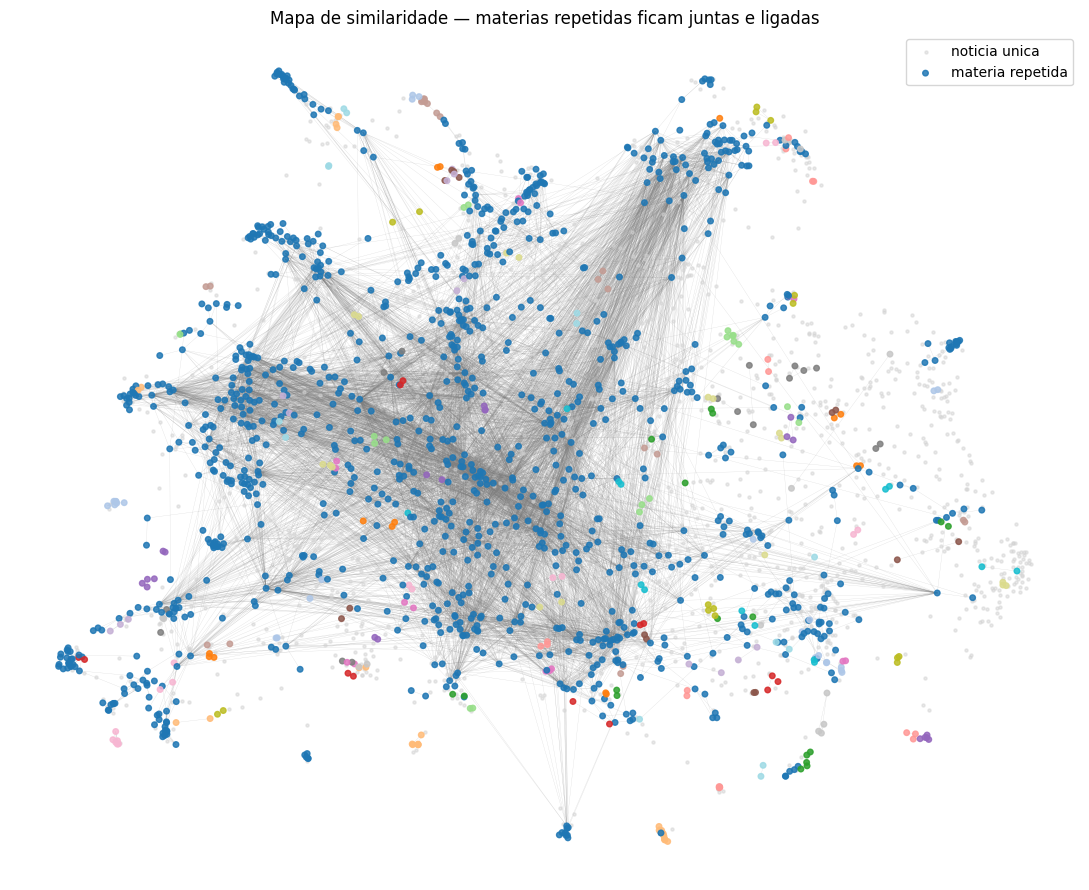

In [8]:
import umap
emb_np = emb.cpu().numpy()
t0 = time.time()
xy = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='cosine',
               random_state=SEED).fit_transform(emb_np)
print('umap', round(time.time()-t0, 1), 's')

mask = df.cluster.values >= 0
plt.figure(figsize=(11, 9))
plt.scatter(xy[~mask, 0], xy[~mask, 1], s=5, c='lightgray', alpha=.5, label='noticia unica')
plt.scatter(xy[mask, 0],  xy[mask, 1],  s=16, c=df.cluster.values[mask],
            cmap='tab20', alpha=.85, label='materia repetida')
for _, i, j in dups:   # liga os pares iguais
    plt.plot([xy[i, 0], xy[j, 0]], [xy[i, 1], xy[j, 1]],
             c='gray', lw=.2, alpha=.3, zorder=0)
plt.title('Mapa de similaridade — materias repetidas ficam juntas e ligadas')
plt.legend(loc='best'); plt.axis('off'); plt.tight_layout(); plt.show()

## 8. De onde a notícia partiu?

Regra (por **dia**, ignorando a hora de extração):

- **1 só fonte no dia mais antigo** → ela é a origem; as fontes de dias posteriores são seguidoras → aresta `origem → seguidor`.
- **Várias fontes no mesmo dia mais antigo** (empate por causa da hora de extração) → não dá pra dizer qual foi a 1ª entre elas; todas contam como pioneiras e ligam às fontes de dias *posteriores*.
- **Matéria 100% no mesmo dia** → direção indeterminada, fica de fora do grafo.

In [9]:
fluxo          = Counter()

origem_count   = Counter()   # vezes que a fonte foi pioneira (1o dia)
seguidor_count = Counter()   # vezes que a fonte republicou algo ja publicado antes
status = Counter()           # direcao_clara | empate_no_dia | tudo_mesmo_dia

for c in materias:
    sub  = df.loc[sorted(c), ['fonte', 'dia']].sort_values('dia')
    dia0 = sub['dia'].iloc[0]
    pioneiras  = sub[sub.dia == dia0]['fonte'].unique()
    seguidoras = [f for f in sub[sub.dia > dia0]['fonte'].unique() if f not in pioneiras]

    if len(seguidoras) == 0:
        status['tudo_mesmo_dia'] += 1
        continue
    status['direcao_clara' if len(pioneiras) == 1 else 'empate_no_dia'] += 1
    for org in pioneiras:
        origem_count[org] += 1
        for s in seguidoras:
            fluxo[(org, s)] += 1
    for s in seguidoras:
        seguidor_count[s] += 1

print('direcao clara  :', status['direcao_clara'])
print('empate no dia  :', status['empate_no_dia'])
print('tudo mesmo dia :', status['tudo_mesmo_dia'])

edges = (pd.DataFrame([(a, b, w) for (a, b), w in fluxo.items()],
                      columns=['origem', 'seguidor', 'peso'])
         .sort_values('peso', ascending=False).reset_index(drop=True))
print('\narestas de propagacao:', len(edges))
edges.head(15)

direcao clara  : 68
empate no dia  : 4
tudo mesmo dia : 63

arestas de propagacao: 132


,origem,seguidor,peso
0,DCI Online,Diário do Grande ABC,6
1,Diário do Grande ABC,Folha de S. Paulo,3
2,Valor Econômico,Estadão,3
3,Valor Econômico - Impresso,DCI Online,3
4,Folha de S. Paulo,DCI Online,3
5,DCI Online,Estadão,3
6,Folha da Região,Estadão,3
7,Estadão,Folha de S. Paulo,3
8,Valor Econômico,DCI Online,2
9,Folha da Região,Folha de S. Paulo,2


## 9. Grafo de propagação

Nó = canal de notícia (tamanho = volume de matérias). Cor = **pioneirismo**
(verde = mais origina / vermelho = mais republica). Seta = `origem → quem republicou`,
espessura proporcional ao nº de matérias.

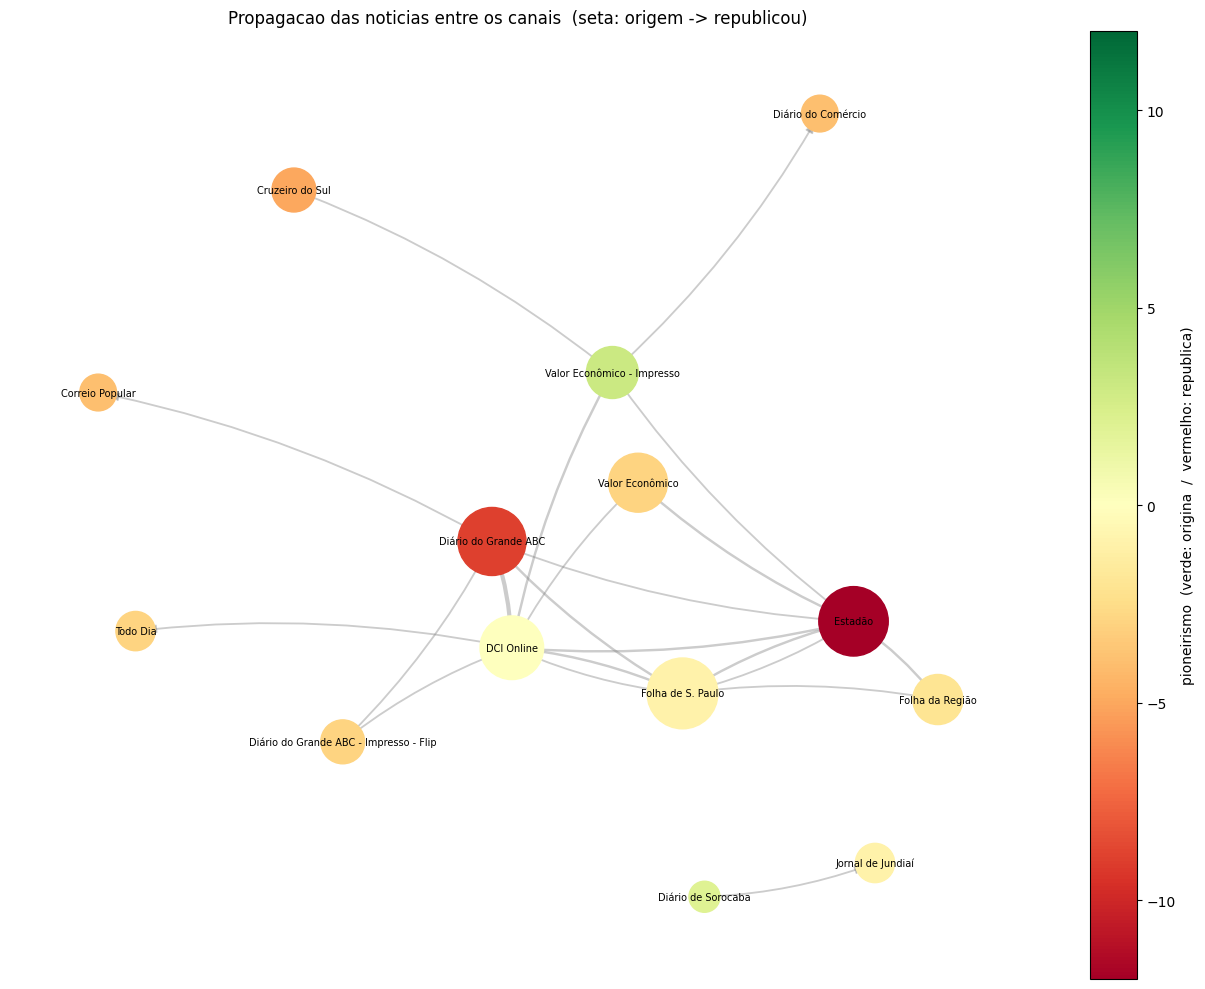

In [10]:
GP = nx.DiGraph()
for _, r in edges.iterrows():
    if r['peso'] >= MIN_PESO_ARESTA:
        GP.add_edge(r['origem'], r['seguidor'], weight=r['peso'])

# mantem so as fontes mais conectadas p/ o grafo nao virar um borrao
graus = dict(GP.degree(weight='weight'))
keep  = [n for n, _ in sorted(graus.items(), key=lambda x: -x[1])[:TOP_FONTES_PLOT]]
H = GP.subgraph(keep).copy()

pion = {n: origem_count[n] - seguidor_count[n] for n in H.nodes}
vlim = max([abs(v) for v in pion.values()] + [1])

pos = nx.spring_layout(H, k=0.9, seed=SEED, weight='weight')
plt.figure(figsize=(13, 10))
nsize = [300 + 100*(origem_count[n] + seguidor_count[n]) for n in H.nodes]
nodes = nx.draw_networkx_nodes(H, pos, node_size=nsize,
            node_color=[pion[n] for n in H.nodes],
            cmap='RdYlGn', vmin=-vlim, vmax=vlim)
w = np.array([H[u][v]['weight'] for u, v in H.edges], dtype=float)
nx.draw_networkx_edges(H, pos, width=0.5 + 2.5*w/w.max(), alpha=.4,
            edge_color='gray', arrowsize=12, connectionstyle='arc3,rad=0.08')
nx.draw_networkx_labels(H, pos, font_size=7)
plt.colorbar(nodes, label='pioneirismo  (verde: origina  /  vermelho: republica)')
plt.title('Propagacao das noticias entre os canais  (seta: origem -> republicou)')
plt.axis('off'); plt.tight_layout(); plt.show()

## 10. Ranking: quem dá a notícia primeiro x quem republica

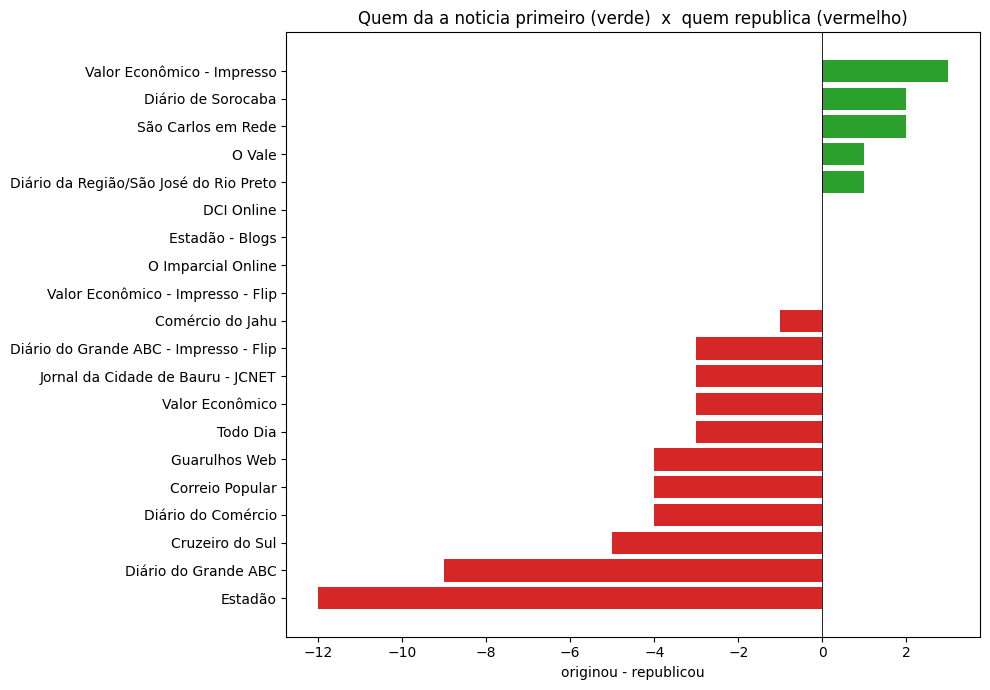

,fonte,originou,republicou,pioneirismo
0,Valor Econômico - Impresso,7,4,3
1,Diário de Sorocaba,2,0,2
2,São Carlos em Rede,2,0,2
3,O Vale,2,1,1
4,Diário da Região/São José do Rio Preto,3,2,1
5,DCI Online,9,9,0
6,Estadão - Blogs,1,1,0
7,O Imparcial Online,1,1,0
8,Valor Econômico - Impresso - Flip,3,3,0
9,Comércio do Jahu,0,1,-1


In [11]:
fontes = sorted(set(list(origem_count) + list(seguidor_count)))
rank = pd.DataFrame({'fonte': fontes})
rank['originou']    = rank.fonte.map(lambda f: origem_count.get(f, 0))
rank['republicou']  = rank.fonte.map(lambda f: seguidor_count.get(f, 0))
rank['pioneirismo'] = rank['originou'] - rank['republicou']
rank = rank.sort_values('pioneirismo', ascending=False).reset_index(drop=True)

top = pd.concat([rank.head(10), rank.tail(10)])
plt.figure(figsize=(10, 7))
plt.barh(top.fonte[::-1], top.pioneirismo[::-1],
         color=['#2ca02c' if v > 0 else '#d62728' for v in top.pioneirismo[::-1]])
plt.axvline(0, c='k', lw=.6)
plt.title('Quem da a noticia primeiro (verde)  x  quem republica (vermelho)')
plt.xlabel('originou - republicou'); plt.tight_layout(); plt.show()

rank.head(15)

## 11. Exportar resultados

In [12]:
df.to_csv('noticias_com_cluster.csv', index=False)
edges.to_csv('propagacao_fonte_a_fonte.csv', index=False)
rank.to_csv('ranking_pioneirismo.csv', index=False)
pd.DataFrame([{'sim': s, 'i': i, 'j': j,
               'fonte_i': df.fonte[i], 'fonte_j': df.fonte[j],
               'dia_i': df.dia[i].date(), 'dia_j': df.dia[j].date(),
               'titulo_i': df.titulo[i], 'titulo_j': df.titulo[j]}
              for s, i, j in dups]).to_csv('pares_duplicados.csv', index=False)
print('salvos: noticias_com_cluster.csv | propagacao_fonte_a_fonte.csv | '
      'ranking_pioneirismo.csv | pares_duplicados.csv')

salvos: noticias_com_cluster.csv | propagacao_fonte_a_fonte.csv | ranking_pioneirismo.csv | pares_duplicados.csv
